<a href="https://colab.research.google.com/github/hernans7/mis433/blob/main/Copy_of_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Analytics

Text analytics turns unstructured language into data that can be counted, compared, visualized, and modeled. Unlike many tabular datasets, text is high-dimensional: a single column of comments, reviews, emails, or news articles can contain thousands of unique words, phrases, spellings, and meanings.

The main challenge is representation. Before we can summarize or model text, we need to decide how to convert language into numeric features while preserving enough meaning for the task. In this notebook, we will practice common steps in that workflow: cleaning and exploring text, converting text to document-term matrices, finding frequent words, measuring word importance with TF-IDF, clustering similar documents, creating word clouds, and estimating sentiment.

# Load and explore data from csv

Source: https://www.kaggle.com/datasets/cloudy17/bob-dylan-songs/

**Context**
This dataset contains songs from years between 1961 to 2020 written by Bob Dylan.

**Content**
There are 4 columns:
* release_year - year when song was released first time,
* album - name of the album where track occurs,
* title - title of the song,
* lyrics - lyrics of the track

In [11]:
import pandas as pd

# load dataset from csv
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/bob-dylan.csv')
df.head(3) # show the first three rows

,release_year,album,title,lyrics
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to..."
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ..."
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...


In [12]:
# shape of the df: rows and columns
df.shape

(345, 4)

In [13]:
# the data types of each column
df.dtypes

,0
release_year,int64
album,object
title,object
lyrics,object


In [14]:
# Get a summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   release_year  345 non-null    int64 
 1   album         345 non-null    object
 2   title         345 non-null    object
 3   lyrics        345 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.9+ KB


In [15]:
# Count the values of a column
df.release_year.value_counts()

,count
release_year,
1975,30
1965,22
1963,22
1964,21
1970,19
1966,15
1967,13
1981,13
1983,13


In [16]:
df.album.value_counts()

,count
album,
"The Bootleg Series, Vol 1-3: Rare & Unreleased 1961-1991",37
The Basement Tapes,16
The Freewheelin',13
Blonde on Blonde,13
New Morning,12
John Wesley Harding,12
“Love and Theft”,12
Bringing It All Back Home,11
Under the Red Sky,10


In [17]:
# Add a new column
df['decade'] = (df['release_year'] // 10) * 10
df.head()

,release_year,album,title,lyrics,decade
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960


In [18]:
# String Operations
# Count the number of words in each song.

df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
df.head()

,release_year,album,title,lyrics,decade,word_count
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960,353
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960,158
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960,391
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960,365
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960,477


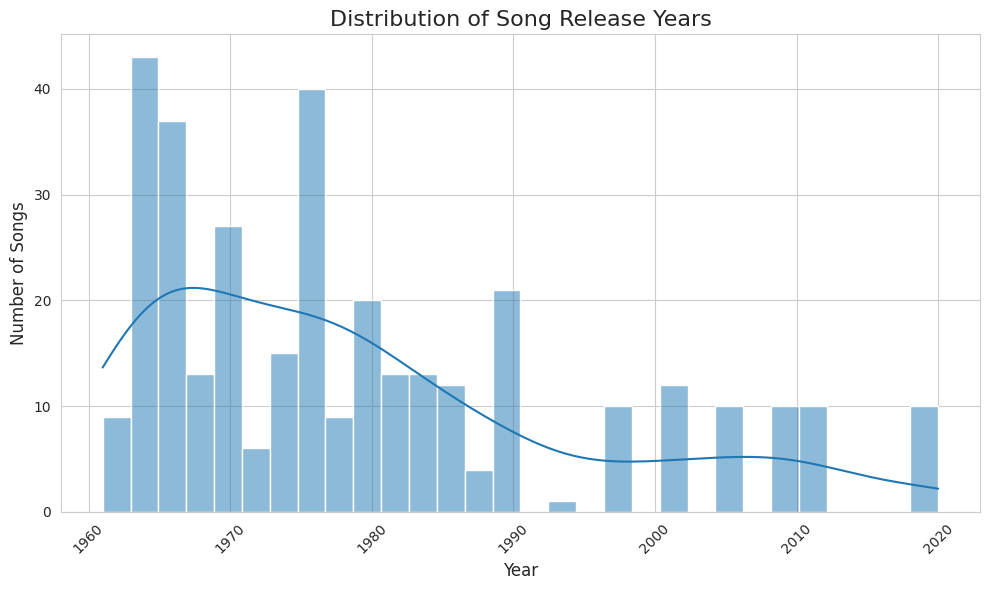

In [19]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Set a prettier style

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.histplot(df['release_year'], bins=30, kde=True) # Use seaborn's histplot with kde for density estimate
plt.title('Distribution of Song Release Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## scikit-learn

Scikit-learn is one of the most popular Python packages for predictive data analysis. It includes tools for preprocessing text, building feature matrices, clustering documents, and training machine learning models.

https://scikit-learn.org/

If scikit-learn is not installed in your environment, uncomment and run the next cell.

In [20]:
# !pip install scikit-learn

### Vectorization: Converting Text to Numeric Form

Text data must be converted into a numeric form before it can be used with machine learning algorithms. A common technique is `CountVectorizer`, which converts a collection of documents into a document-term matrix. Each row is a document, each column is a token, and each value is the number of times that token appears in that document.

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# Example using the 'lyrics' column of the Bob Dylan dataset
corpus = df['lyrics'].dropna().tolist()  # Assuming df is your DataFrame and dropping any missing values
vectorizer = CountVectorizer(stop_words='english')  # Remove common 'stop words'
X = vectorizer.fit_transform(corpus)

print(X.shape)  # Shows the shape of the matrix


(345, 7326)


In [22]:
# Accessing the Vocabulary
vocabulary = vectorizer.vocabulary_

# Print the vocabulary dictionary (word: column index)
print(vocabulary)

{'come': 1220, 'ladies': 3508, 'gentlemen': 2630, 'listen': 3691, 'song': 5938, 'sing': 5777, 'right': 5267, 'think': 6491, 'wrong': 7278, 'just': 3423, 'little': 3698, 'glimpse': 2681, 'story': 6172, 'll': 3707, 'tell': 6439, 'bout': 662, 'east': 1989, 'coast': 1182, 'city': 1111, 'know': 3492, 'hard': 2896, 'times': 6558, 'livin': 3704, 'new': 4247, 'york': 7313, 'town': 6627, 'old': 4352, 'friendly': 2531, 'washington': 7031, 'heights': 2981, 'harlem': 2902, 'mighty': 4008, 'people': 4601, 'millin': 4015, 'kick': 3443, 'knock': 3484, 'long': 3731, 'ways': 7056, 'golden': 2706, 'gate': 2605, 'rockefeller': 5321, 'plaza': 4741, 'empire': 2045, 'state': 6108, 'mister': 4055, 'sets': 5607, 'high': 3011, 'bird': 501, 'says': 5488, 'word': 7229, 'country': 1373, 'mornin': 4113, 'tryin': 6734, 'job': 3371, 'work': 7232, 'stand': 6079, 'place': 4706, 'till': 6552, 'feet': 2270, 'begin': 438, 'hurt': 3161, 'got': 2727, 'lot': 3760, 'money': 4084, 'make': 3847, 'merry': 3984, 'nickel': 4256, 

In [23]:
# Size of the vocabulary
len(vocabulary)

7326

In [24]:
# View the first document's feature vector
document_index = 0
feature_vector_sparse = X.getrow(document_index)

# To convert to a dense array
feature_vector_dense = feature_vector_sparse.toarray()

print(feature_vector_dense)

[[0 0 0 ... 0 0 0]]


In [25]:
# To View as a Readable Format

# Get feature names
feature_words = vectorizer.get_feature_names_out()

# Convert the sparse matrix row to a dense array
feature_vector_array = feature_vector_sparse.toarray().flatten()

# Create a dictionary mapping feature names to their values for the document
document_features = {feature_words[i]: int(feature_vector_array[i])
                     for i in range(len(feature_words)) if feature_vector_array[i] != 0}

print(document_features)

{'ay': 1, 'beat': 1, 'begin': 1, 'bird': 1, 'bit': 1, 'bought': 1, 'bout': 1, 'cal': 1, 'caves': 1, 'city': 9, 'cleaner': 1, 'coast': 1, 'come': 2, 'country': 1, 'dirt': 1, 'dream': 1, 'dust': 1, 'east': 1, 'empire': 2, 'feet': 2, 'ferry': 1, 'friendly': 1, 'gate': 1, 'gentlemen': 1, 'glimpse': 1, 'golden': 1, 'got': 2, 'hard': 7, 'harlem': 1, 'heights': 1, 'high': 1, 'hudson': 1, 'hurt': 1, 'island': 1, 'job': 1, 'just': 1, 'kick': 1, 'kind': 1, 'knock': 1, 'know': 1, 'ladies': 1, 'leave': 1, 'listen': 3, 'little': 1, 'livin': 7, 'll': 4, 'long': 1, 'lot': 1, 'make': 1, 'merry': 1, 'mighty': 2, 'millin': 1, 'mines': 1, 'minuet': 1, 'mister': 4, 'money': 1, 'mornin': 1, 'mountain': 1, 'ne': 1, 'new': 10, 'news': 1, 'newsy': 1, 'nickel': 1, 'oklahoma': 1, 'old': 4, 'paid': 1, 'people': 2, 'place': 1, 'plains': 1, 'plaza': 1, 'right': 2, 'rockefeller': 2, 'rocky': 1, 'sailin': 1, 'says': 1, 'sell': 1, 'sets': 1, 'sing': 1, 'smog': 1, 'song': 2, 'spread': 1, 'stand': 1, 'standin': 1, 'sta

In [26]:
# Getting the Most Frequent Words

import numpy as np

# Sum up the counts of each word across all documents
word_counts = np.sum(X.toarray(), axis=0)  # X is the result of vectorizer.fit_transform(corpus)

# Map from feature index to word
feature_words = vectorizer.get_feature_names_out()

# Combine counts and words into a dictionary, ensuring counts are Python integers
word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

# Sort the dictionary by counts in descending order to get the most frequent words
sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_words = 20  # You can adjust N as needed
print(sorted_word_count[:top_n_words])

[('don', 553), ('like', 496), ('just', 477), ('got', 465), ('ll', 451), ('know', 418), ('love', 301), ('gonna', 296), ('man', 287), ('time', 273), ('ve', 273), ('ain', 271), ('said', 265), ('come', 253), ('say', 252), ('oh', 241), ('tell', 219), ('baby', 207), ('way', 195), ('day', 192)]


/tmp/ipykernel_3590/531371955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')


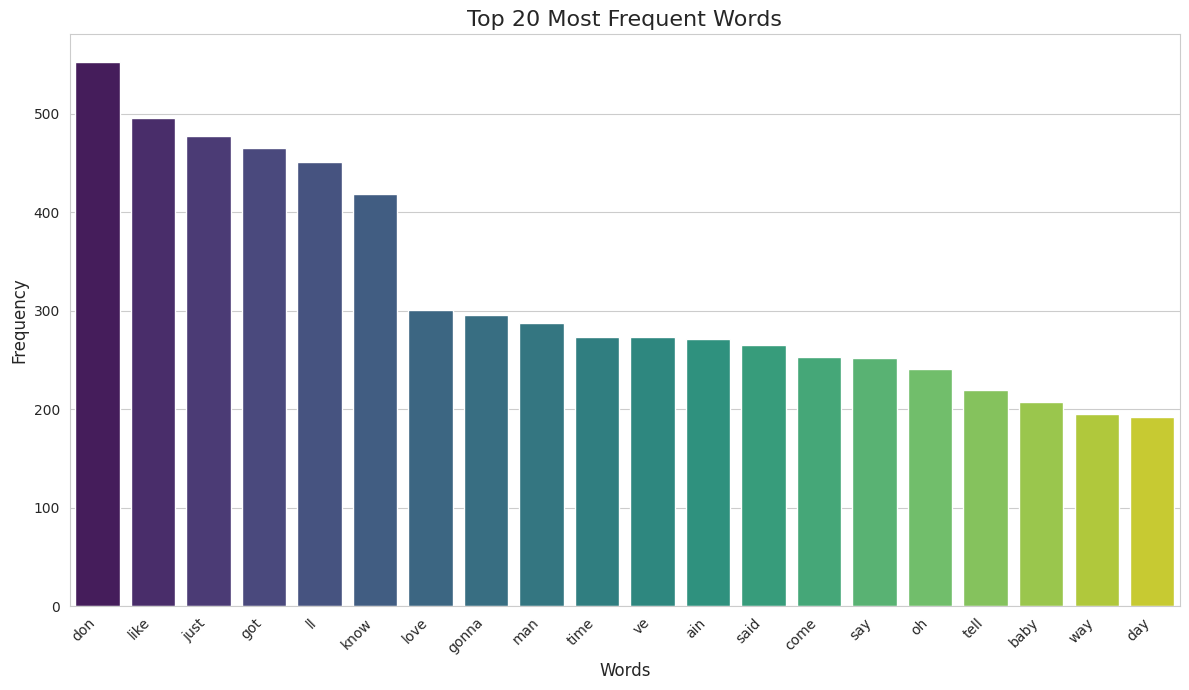

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract words and counts from the sorted_word_count list
words = [item[0] for item in sorted_word_count[:top_n_words]]
counts = [item[1] for item in sorted_word_count[:top_n_words]]

# Create a DataFrame for easier plotting with seaborn
most_frequent_words_df = pd.DataFrame({'Word': words, 'Count': counts})

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### TF-IDF: Weighing Word Importance

TF-IDF stands for term frequency-inverse document frequency. It gives higher scores to words that appear often in a particular document but not too often across the entire collection. This helps reduce the influence of common words and highlight words that are more distinctive for a song.

In practice, TF-IDF is often more useful than raw word counts for comparing documents because it balances local importance with overall rarity.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print(X_tfidf.shape)


(345, 7326)


### Clustering: Grouping Similar Songs

With the numeric representations, you can now perform clustering to group similar songs.

**K-means** is a popular algorithm that can partition a set of data points into K groups, where K is predefined.

In [29]:
from sklearn.cluster import KMeans

# Using TF-IDF vectors for clustering
kmeans = KMeans(n_clusters=5, random_state=0)  # Assuming we want to cluster into 5 groups
kmeans.fit(X_tfidf)

# Print cluster labels for each song
print(kmeans.labels_)

# Count the number of songs in each cluster (from KMeans)
cluster_counts = np.bincount(kmeans.labels_)

print("KMeans Cluster Sizes:")
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} songs")

[3 4 3 3 4 1 3 3 3 4 3 2 2 3 1 3 3 3 4 3 1 3 3 1 1 4 4 4 4 3 4 3 3 4 0 3 4
 1 1 0 1 3 3 3 3 1 0 3 1 4 3 3 1 3 2 1 3 3 3 3 3 3 4 0 1 3 4 1 1 1 3 1 4 3
 4 1 3 2 3 4 3 1 3 1 1 3 0 2 3 4 1 4 3 2 4 4 3 1 1 2 4 3 3 1 1 2 0 3 3 3 3
 4 4 0 4 4 3 3 3 2 0 3 0 4 4 0 1 1 2 3 3 0 3 3 3 3 1 3 0 3 1 1 3 2 3 3 1 2
 1 2 1 1 3 0 4 2 4 4 1 0 3 3 3 1 1 3 0 3 0 4 1 4 4 1 3 3 3 4 1 3 4 4 0 2 4
 3 4 2 4 0 1 3 3 1 4 1 3 1 3 1 3 1 1 0 4 3 1 1 3 1 4 1 3 2 1 0 2 3 1 1 1 0
 3 3 4 1 3 3 0 3 3 3 0 2 3 2 1 3 1 3 1 1 4 3 4 3 1 1 1 3 2 3 3 3 0 3 0 4 1
 3 3 3 1 4 1 1 1 3 4 4 3 3 4 3 3 3 1 3 3 4 3 0 4 3 3 3 3 3 2 3 3 2 3 3 3 3
 3 3 3 4 3 1 3 3 3 3 3 3 1 3 1 1 3 1 3 1 2 1 3 3 3 3 1 1 3 3 3 3 3 2 3 4 3
 1 1 1 4 2 3 3 3 3 3 2 3]
KMeans Cluster Sizes:
Cluster 0: 26 songs
Cluster 1: 82 songs
Cluster 2: 27 songs
Cluster 3: 154 songs
Cluster 4: 56 songs


**Hierarchical Clustering** is a different algorithm that agglomeratively groups similar objects into clusters, eventually forming a tree (hierarchy) of clusters.

Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):


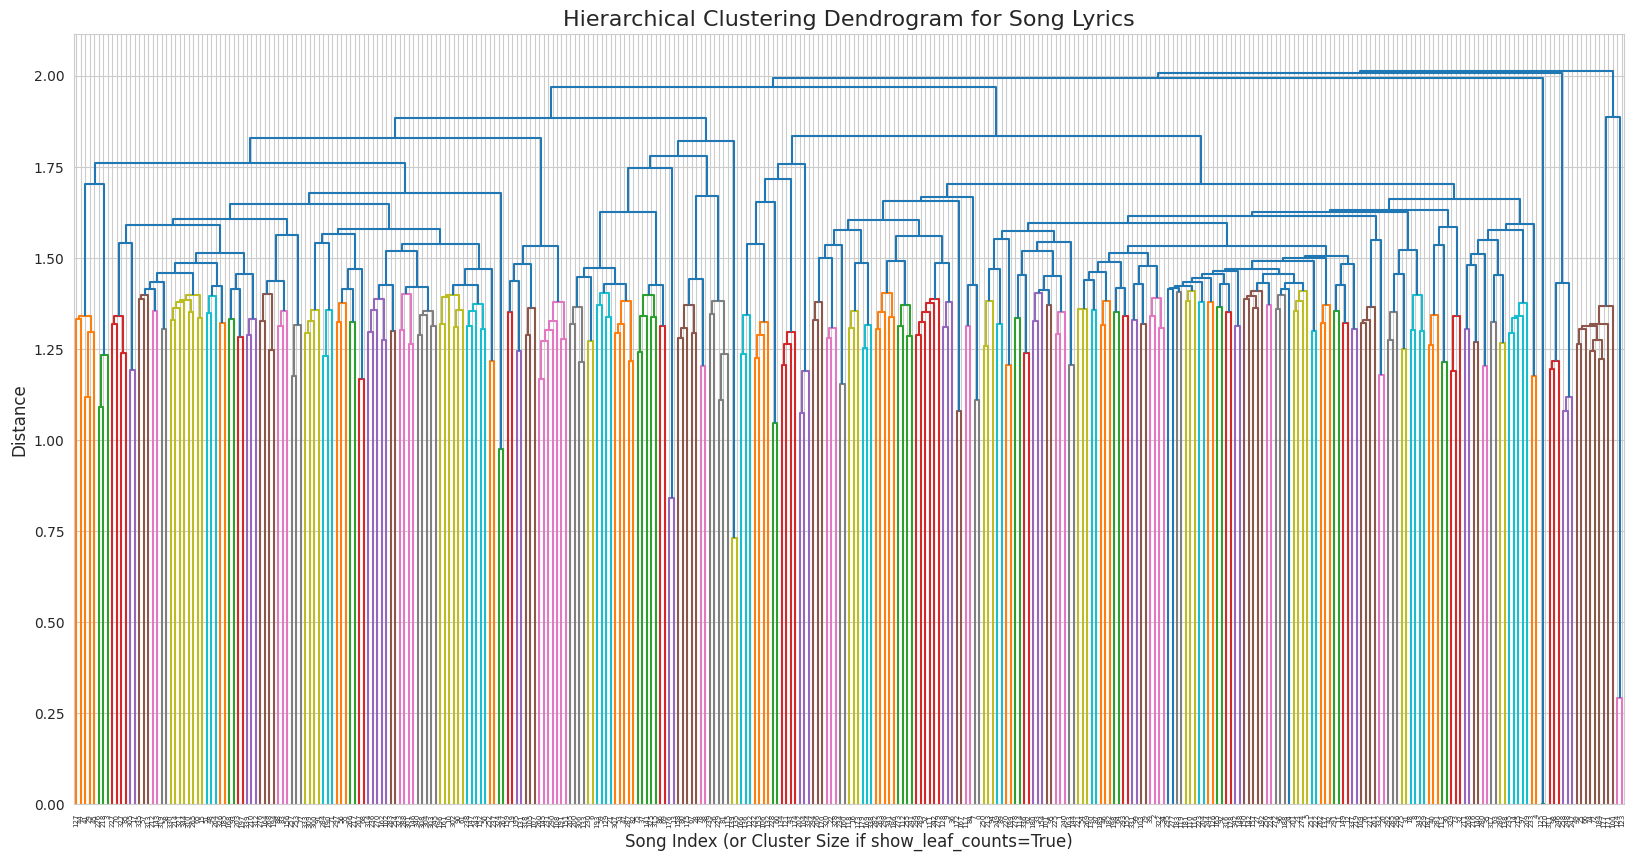

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

print("Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):")

# Perform hierarchical clustering on the TF-IDF vectors
# 'ward' linkage minimizes the variance of the clusters being merged.
# You can choose other methods like 'complete', 'average', 'single'.
linked = linkage(X_tfidf.toarray(), 'ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram for Song Lyrics', fontsize=16)
plt.xlabel('Song Index (or Cluster Size if show_leaf_counts=True)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

### Create a Word Cloud

A word cloud is a quick visual summary of common words. It is easy to read, but it should be treated as exploratory rather than analytical because it does not show exact counts or account for context.

In [31]:
# Install wordcloud package
#!pip install --upgrade wordcloud

In [32]:
# You may need to run this too.
#!pip install --upgrade Pillow

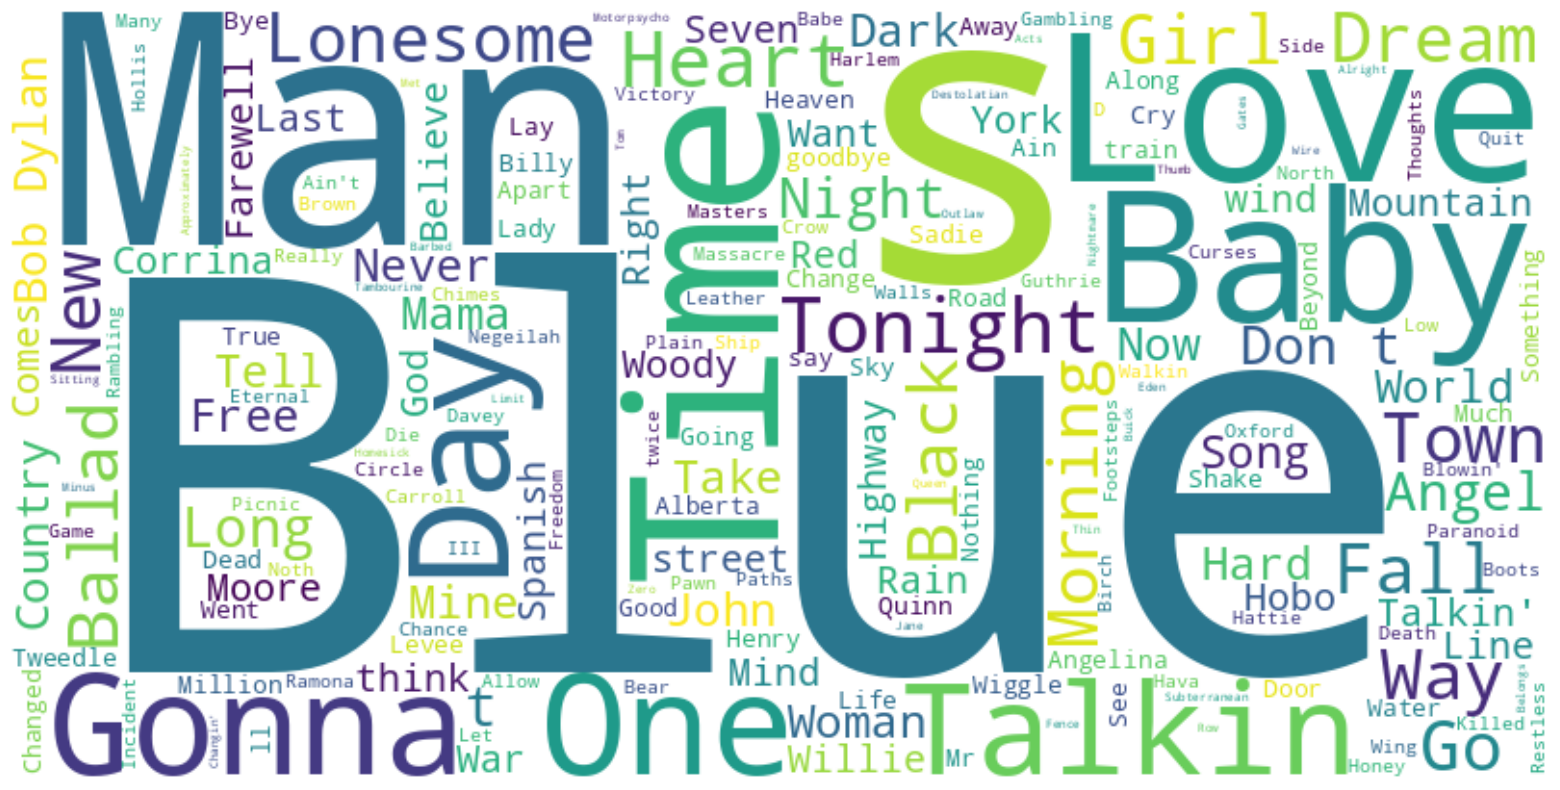

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all the text in the 'title' column into a single string
all_titles_text = " ".join(title for title in df['title'])

# Generate a word cloud image
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(all_titles_text)

# Display the generated image
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


### Sentiment Analysis with a Pre-trained Model

For a simple sentiment analysis, you can use a pre-trained model from libraries such as TextBlob to estimate the sentiment score expressed in text.

TextBlob: https://textblob.readthedocs.io/en/dev/

In [34]:
# Install TextBlob
!pip install textblob

In [35]:
# This example uses TextBlob for sentiment analysis
from textblob import TextBlob

# Sample usage with the first five song's lyrics
for i in range(5):
    title = df['title'].iloc[i]
    lyrics = df['lyrics'].iloc[i]
    blob = TextBlob(lyrics)
    score = blob.sentiment.polarity
    print(f"{title}\t{lyrics[:25]}...\t{score}")

Hard Times In New York Town	Come you ladies and you g...	0.011896504729838058
Man on the street	’ll sing you a song, ain’...	-0.0692063492063492
Talkin’ Bear Mountain Picnic Massacre Blues	I saw it advertised one d...	0.14592111592111595
Let Me Die in My Footsteps	I will not go down under ...	-0.04433742183742184
Rambling, Gambling Willie	Come around you rovin’ ga...	-0.014664989664989669


## Exercises

Try these exercises to practice adapting the workflow above. Start by writing the code yourself, then compare your result with a partner or instructor.

In [36]:
# Exercise 1: Find the top 10 frequent words in Dylan's songs for each decade.
# Hint: loop through text_df.groupby('decade'), then fit a CountVectorizer to each decade's lyrics.
# Loop through each decade
for decade, group in df.groupby('decade'):

    # Combine all lyrics from the decade into one large string
    lyrics = " ".join(group['lyrics'].dropna())

    # Create CountVectorizer
    vectorizer = CountVectorizer(stop_words='english')

    # Fit and transform the lyrics
    word_matrix = vectorizer.fit_transform([lyrics])

    # Get word counts
    word_counts = word_matrix.toarray()[0]

    # Get feature names (words)
    words = vectorizer.get_feature_names_out()

    # Create dataframe of words and counts
    freq_df = pd.DataFrame({
        'word': words,
        'count': word_counts
    })

    # Sort by frequency and get top 10
    top_words = freq_df.sort_values(by='count', ascending=False).head(10)

    # Print results
    print(f"\nTop 10 words for the {decade}s:")
    print(top_words.to_string(index=False))


Top 10 words for the 1960s:
word  count
just    182
 don    152
like    142
  ll    138
 got    135
 ain    127
know    126
said    103
come     88
  oh     84

Top 10 words for the 1970s:
 word  count
 like    146
  don    140
gonna    125
 just    113
 said     98
 know     94
   ll     91
   oh     90
 time     89
   ve     85

Top 10 words for the 1980s:
word  count
 don    135
 got    110
know    105
like     97
just     96
love     87
 man     67
time     64
  ll     60
  ve     59

Top 10 words for the 1990s:
  word  count
wiggle     55
  like     42
   don     36
   got     31
   god     28
  know     27
   til     27
  just     26
 knows     22
  love     21

Top 10 words for the 2000s:
 word  count
  got     77
  don     57
   ll     52
gonna     51
 just     44
 know     44
  day     41
  say     41
  ain     39
 good     39

Top 10 words for the 2010s:
  word  count
    ll     44
  long     32
blowin     22
  work     22
   way     20
  like     18
 heart     16
   day    

<Axes: xlabel='decade', ylabel='sentiment_polarity'>

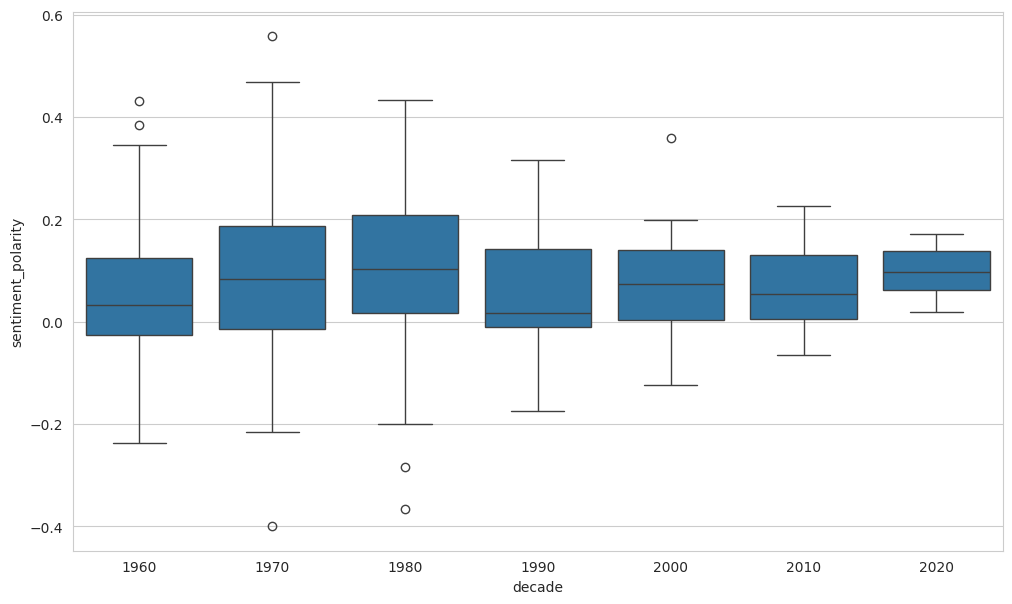

In [37]:
# Exercise 2: Create a boxplot showing sentiment scores across decades.
# Hint: use x='decade' and y='sentiment_polarity' with sns.boxplot().
df['sentiment_polarity'] = df['lyrics'].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(12, 7))
sns.boxplot(x='decade', y='sentiment_polarity', data=df)

## Working with Text Data from an API

Many API responses contain text data. For instance, the [NewsAPI](https://newsapi.org/) searches articles and breaking-news headlines from news sources and blogs across the web.

In this section, we will search recent news articles and convert the results into a DataFrame for text analysis.

To use the NewsAPI, you'll need an API key. It's recommended to store your API key securely in Colab's secrets manager under the "🔑" icon in the left panel. Name the secret `NEWS_API_KEY`.

In [38]:
from google.colab import userdata

NEWS_API_KEY = userdata.get('NEWS_API_KEY')
print(f"API Key: {NEWS_API_KEY}")

API Key: d4c7b27c5e7044fea6f7fba63eee473d


In [39]:
import datetime

# Get today's date
today = datetime.date.today()

# Calculate the date three days ago
three_days_ago = today - datetime.timedelta(days=3)

# Format the date for the API request (YYYY-MM-DD)
from_param = three_days_ago.strftime('%Y-%m-%d')

print(f"Fetching news from: {from_param} to {today.strftime('%Y-%m-%d')}")

Fetching news from: 2026-05-25 to 2026-05-28


In [40]:
import requests
import pandas as pd # Import pandas for DataFrame

query = input("Please enter your search query for news articles: ")
print(f"Searching for articles related to: {query}")

# NewsAPI endpoint for all articles
url = 'https://newsapi.org/v2/everything'

# Parameters for the request
params = {
    'pageSize': 100,    # Max number of articles to retrieve per request for 'everything' endpoint
    'apiKey': NEWS_API_KEY,
    'q': query, # The search query
    'from': from_param, # Start date for the search (already calculated)
    'to': today.strftime('%Y-%m-%d'), # End date for the search (today)
    'language': 'en' # Filter for English language articles
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()

    print("Successfully fetched news articles.")

    articles_data = []
    for article in data['articles']:
        source_name = article.get('source', {}).get('name', 'N/A')
        articles_data.append({
            'title': article.get('title'),
            'author': article.get('author'),
            'source': source_name,
            'description': article.get('description'),
            'date': article.get('publishedAt')
        })

    news_df = pd.DataFrame(articles_data)

    print(f"Total articles retrieved and saved to DataFrame: {len(news_df)}")
    print(f"Total results matching query (available from API): {data['totalResults']}")
    display(news_df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching news: {e}")
    if response.status_code == 401:
        print("Unauthorized: Check your API key.")
    elif response.status_code == 429:
        print("Too Many Requests: You may have hit your API rate limit.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Please enter your search query for news articles: Bomb
Searching for articles related to: Bomb
Successfully fetched news articles.
Total articles retrieved and saved to DataFrame: 96
Total results matching query (available from API): 186


,title,author,source,description,date
0,Iran live updates: Peace deal a 'work in progr...,David Brennan,Abcnews.com,"President Donald Trump announced ""major combat...",2026-05-25T05:43:18Z
1,Prospects fade for imminent end to Iran war as...,Jane Arraf,NPR,Israel says it will intensify attacks against ...,2026-05-26T13:32:50Z
2,Train bomb in Pakistan’s Baloch region: Why vi...,Sarah Shamim,Al Jazeera English,Deadly blast in Pakistan marks uptick in Baloc...,2026-05-25T15:43:21Z
3,Trump Sure Picked the Worst Time Imaginable to...,Ellie Quinlan Houghtaling,The New Republic,The U.S. bombed several Iranian targets Monday...,2026-05-26T13:38:05Z
4,Trump’s War Is Staggering to an Incoherent Defeat,Tom Nichols,The Atlantic,Even the president’s supporters are alarmed.,2026-05-25T00:12:40Z


### Analyze the Text in the News Articles

What questions can we ask about this dataset?

- Which words appear most often in article titles or descriptions?
- Do different sources use different language for the same topic?
- How does sentiment vary across articles or sources?
- Are there clusters of articles that focus on different subtopics?

### Question 1: Which words appear most often in article titles or descriptions?

In [41]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Combine titles and descriptions into a single text field for analysis
news_df['full_text'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')

# Initialize CountVectorizer to remove English stop words
news_vectorizer = CountVectorizer(stop_words='english')

# Fit and transform the full_text column
X_news = news_vectorizer.fit_transform(news_df['full_text'])

# Sum up the counts of each word across all documents
news_word_counts = np.sum(X_news.toarray(), axis=0)

# Get feature names (words) from the vectorizer
news_feature_words = news_vectorizer.get_feature_names_out()

# Combine counts and words into a dictionary
news_word_count_dict = {word: int(count) for word, count in zip(news_feature_words, news_word_counts)}

# Sort the dictionary by counts in descending order
sorted_news_word_count = sorted(news_word_count_dict.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_news_words = 20
print(f"Top {top_n_news_words} most frequent words in news articles:")
for word, count in sorted_news_word_count[:top_n_news_words]:
    print(f"- {word}: {count}")

Top 20 most frequent words in news articles:
- trump: 26
- north: 24
- korea: 23
- iran: 21
- bomb: 19
- deal: 13
- new: 13
- day: 11
- military: 10
- missile: 10
- sea: 10
- ballistic: 9
- force: 9
- missiles: 9
- peace: 9
- south: 9
- year: 9
- post: 8
- president: 8
- said: 8


/tmp/ipykernel_3590/2573432351.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_news_words_df, palette='viridis')


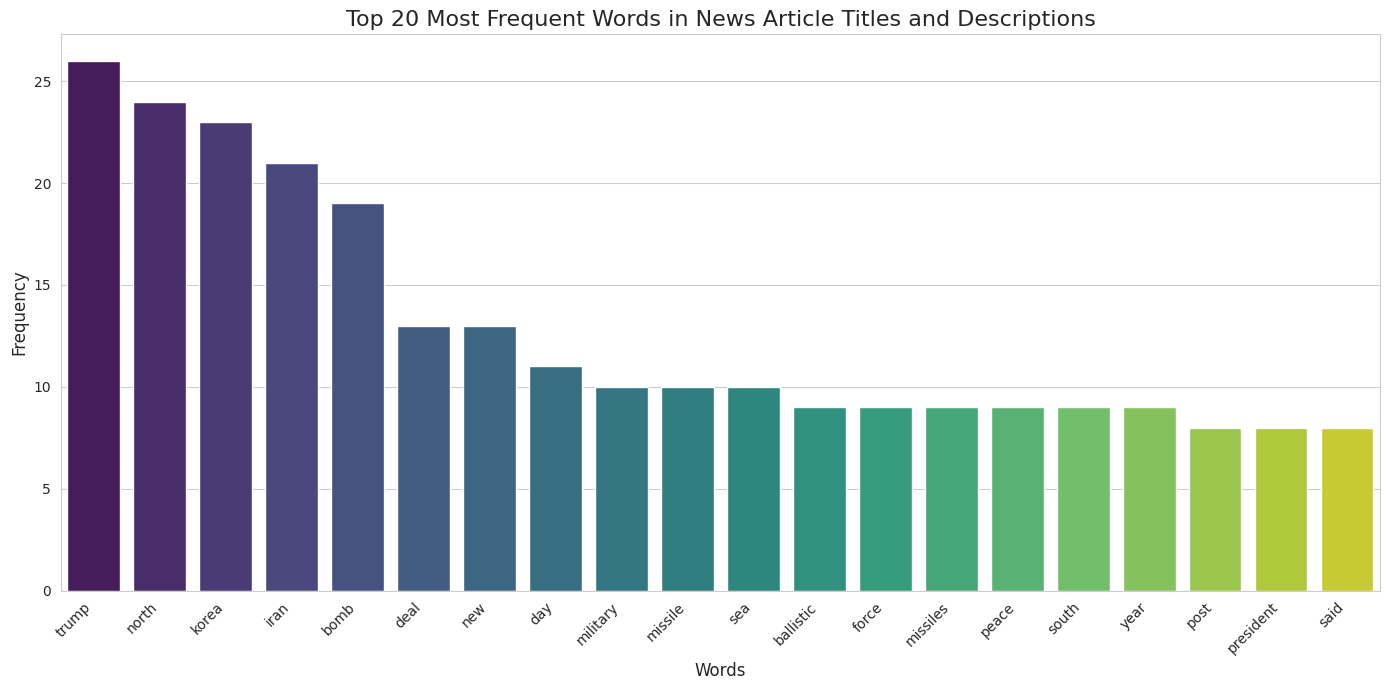

In [42]:
# Extract words and counts for plotting
news_words = [item[0] for item in sorted_news_word_count[:top_n_news_words]]
news_counts = [item[1] for item in sorted_news_word_count[:top_n_news_words]]

# Create a DataFrame for easier plotting
most_frequent_news_words_df = pd.DataFrame({'Word': news_words, 'Count': news_counts})

# Create the bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_news_words_df, palette='viridis')
plt.title(f'Top {top_n_news_words} Most Frequent Words in News Article Titles and Descriptions', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Question 2: Do different sources use different language for the same topic?

In [43]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

print("Top 10 most frequent words per news source:")

for source_name, group_df in news_df.groupby('source'):
    if len(group_df) > 0:
        # Combine full_text for the current source
        source_full_text = " ".join(group_df['full_text'].dropna())

        if source_full_text:
            # Create a new CountVectorizer for each source to get specific word frequencies
            source_vectorizer = CountVectorizer(stop_words='english')
            X_source = source_vectorizer.fit_transform([source_full_text])

            # Sum word counts
            source_word_counts = np.sum(X_source.toarray(), axis=0)
            source_feature_words = source_vectorizer.get_feature_names_out()

            # Create dictionary and sort
            source_word_count_dict = {word: int(count) for word, count in zip(source_feature_words, source_word_counts)}
            sorted_source_word_count = sorted(source_word_count_dict.items(), key=lambda x: x[1], reverse=True)

            print(f"\n--- Source: {source_name} ---")
            for word, count in sorted_source_word_count[:10]:
                print(f"- {word}: {count}")
        else:
            print(f"\n--- Source: {source_name} ---")
            print("No text available for this source.")
    else:
        print(f"\n--- Source: {source_name} ---")
        print("No articles found for this source.")

Top 10 most frequent words per news source:

--- Source: ABC News (AU) ---
- airport: 2
- home: 2
- largest: 2
- making: 2
- man: 2
- missile: 2
- russia: 2
- security: 2
- strikes: 2
- 30: 1

--- Source: Abcnews.com ---
- korea: 3
- ballistic: 2
- iran: 2
- missiles: 2
- north: 2
- says: 2
- sea: 2
- 28: 1
- announced: 1
- close: 1

--- Source: Activistpost.com ---
- trump: 2
- accept: 1
- america: 1
- catastrophic: 1
- chris: 1
- defeat: 1
- depression: 1
- east: 1
- ensuring: 1
- global: 1

--- Source: Al Jazeera English ---
- ballroom: 2
- pakistan: 2
- region: 2
- trump: 2
- violence: 2
- 1bn: 1
- action: 1
- administration: 1
- baloch: 1
- balochistan: 1

--- Source: Alltoc.com ---
- streaming: 3
- bale: 2
- box: 2
- christian: 2
- office: 2
- audience: 1
- bomb: 1
- classic: 1
- described: 1
- earning: 1

--- Source: Anfieldwatch.co.uk ---
- dara: 2
- jikiemi: 2
- liverpool: 2
- transfer: 2
- agree: 1
- agreed: 1
- busy: 1
- club: 1
- edwards: 1
- focuse: 1

--- Source: BBC News

### Question 3: How does sentiment vary across articles or sources?

News articles with sentiment polarity:


,title,source,sentiment_polarity
0,Iran live updates: Peace deal a 'work in progr...,Abcnews.com,0.066288
1,Prospects fade for imminent end to Iran war as...,NPR,-0.100000
2,Train bomb in Pakistan’s Baloch region: Why vi...,Al Jazeera English,-0.200000
3,Trump Sure Picked the Worst Time Imaginable to...,The New Republic,0.100000
4,Trump’s War Is Staggering to an Incoherent Defeat,The Atlantic,-0.200000



Average sentiment polarity by news source:


,sentiment_polarity
source,
Dodgers Nation,0.500000
Wonkette.com,0.409091
Democracy Now!,0.315476
Fox Sports,0.312500
The Atlantic,0.300000
...,...
Breitbart News,-0.159722
Deadline,-0.166667
Thefreedomfrequency.org,-0.200000


/tmp/ipykernel_3590/1597260500.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='source', y='sentiment_polarity', data=news_df, palette='coolwarm')


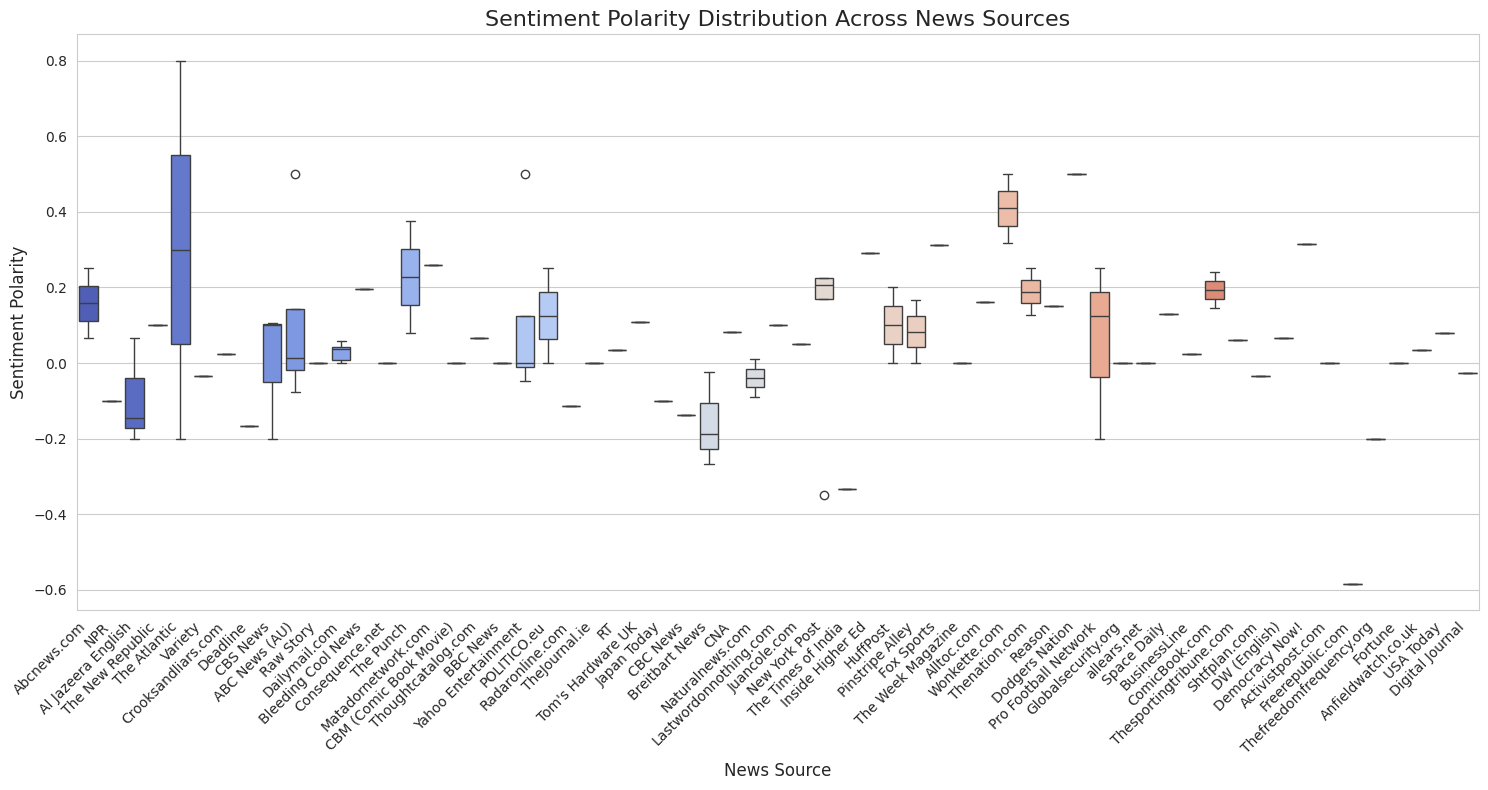

In [44]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate sentiment polarity for each article
news_df['sentiment_polarity'] = news_df['full_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Display the DataFrame with sentiment scores
print("News articles with sentiment polarity:")
display(news_df[['title', 'source', 'sentiment_polarity']].head())

# Calculate average sentiment polarity per source
sentiment_by_source = news_df.groupby('source')['sentiment_polarity'].mean().sort_values(ascending=False)

print("\nAverage sentiment polarity by news source:")
display(sentiment_by_source)

# Visualize sentiment distribution across sources using a boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(x='source', y='sentiment_polarity', data=news_df, palette='coolwarm')
plt.title('Sentiment Polarity Distribution Across News Sources', fontsize=16)
plt.xlabel('News Source', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Question 4: Are there clusters of articles that focus on different subtopics?

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import pandas as pd

# Use full_text for TF-IDF vectorization
news_corpus = news_df['full_text'].dropna().tolist()

tfidf_vectorizer_news = TfidfVectorizer(stop_words='english')
X_tfidf_news = tfidf_vectorizer_news.fit_transform(news_corpus)

# Determine an optimal number of clusters (e.g., using Elbow method or just choosing a reasonable number)
n_clusters = 5 # Starting with 5 clusters, this can be adjusted
kmeans_news = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Set n_init to suppress warning
kmeans_news.fit(X_tfidf_news)

# Add cluster labels to the news_df (handle potential NaN in full_text)
news_df_clustered = news_df.copy()
news_df_clustered = news_df_clustered[news_df_clustered['full_text'].notna()]
news_df_clustered['cluster'] = kmeans_news.labels_

print("Distribution of articles per cluster:")
print(news_df_clustered['cluster'].value_counts().sort_index())

# Function to get top words for each cluster
def get_top_cluster_words(model, vectorizer, n_words):
    feature_names = vectorizer.get_feature_names_out()
    top_words = {}
    for i, centroid in enumerate(model.cluster_centers_):
        centroid_words = [feature_names[idx] for idx in centroid.argsort()[:-n_words - 1:-1]]
        top_words[f'Cluster {i}'] = centroid_words
    return top_words

# Get and print top words for each cluster
top_words_per_cluster = get_top_cluster_words(kmeans_news, tfidf_vectorizer_news, 10)
print("\nTop words per cluster:")
for cluster, words in top_words_per_cluster.items():
    print(f"{cluster}: {', '.join(words)}")

# Display some articles from each cluster to get a sense of the subtopic
print("\nSample articles from each cluster:")
for i in range(n_clusters):
    print(f"\n--- Cluster {i} ---")
    display(news_df_clustered[news_df_clustered['cluster'] == i][['title', 'source']].head(3))

Distribution of articles per cluster:
cluster
0     8
1    65
2     9
3     7
4     7
Name: count, dtype: int64

Top words per cluster:
Cluster 0: years, major, pollen, release, end, genre, roberts, scoreless, bullpen, finale
Cluster 1: trump, iran, deal, bomb, president, peace, post, week, war, security
Cluster 2: cowser, thriller, hits, james, aaron, exclusive, ignition, rodgers, walk, break
Cluster 3: korea, north, sea, missiles, ballistic, south, military, range, missile, seoul
Cluster 4: berlin, station, power, border, built, modern, core, steel, key, glass

Sample articles from each cluster:

--- Cluster 0 ---


,title,source
14,The Mali crisis could have a dangerous spillov...,Al Jazeera English
25,Baltics turn to Ukraine for bomb shelter exper...,POLITICO.eu
30,Employment services to get largest overhaul in...,ABC News (AU)



--- Cluster 1 ---


,title,source
0,Iran live updates: Peace deal a 'work in progr...,Abcnews.com
1,Prospects fade for imminent end to Iran war as...,NPR
2,Train bomb in Pakistan’s Baloch region: Why vi...,Al Jazeera English



--- Cluster 2 ---


,title,source
5,Maisie Williams Thriller ‘Ignition’ Sells to U...,Variety
8,Brian Geraghty Joins Chris Hemsworth & Taron E...,Deadline
9,Remembering CBS News' Paul Douglas and James B...,CBS News



--- Cluster 3 ---


,title,source
23,North Korea fires several short-range ballisti...,CBS News
31,"North Korea fired several missiles, South Kore...",Japan Today
38,North Korea fires ballistic missile into Yello...,CNA



--- Cluster 4 ---


,title,source
27,Irish army bomb disposal experts called to dea...,TheJournal.ie
28,Baltic state warns boaters near Russian border,RT
29,Intel’s new Bartlett Lake flagship loses fight...,Tom's Hardware UK
